# Producto MEDI a nivel AGEB urbana (Censo 2020) → `data/derived/INEGI/2020/`

Paso **S2** de `docs/planes/03-capas-inegi-medi.md`. Construye el GeoParquet
`medi_ageb_2020.parquet` con los cuatro indicadores MEDI que el ITER mide
en el universo censal (los otros tres del MEDI son estatales):

| indicador | fórmula | peso MEDI |
|---|---|---|
| sin electricidad | `VPH_S_ELEC / VIVPARH_CV` | 0.24 |
| sin refrigerador | `(VIVPARH_CV − VPH_REFRI) / VIVPARH_CV` | 0.21 |
| sin teléfono fijo ni celular | `VPH_SINLTC / VIVPARH_CV` | 0.08 |
| sin radio ni televisor | `VPH_SINRTV / VIVPARH_CV` | 0.07 |

**Fuente:** los 32 archivos oficiales *Principales resultados por AGEB y
manzana urbana* del Censo 2020 (INEGI, datos abiertos), no el extracto
`bd_MEDI_AGEB.csv`. Razón: el extracto trae `VIVPAR_HAB` como denominador,
pero los indicadores `VPH_*` de INEGI se calculan sobre `VIVPARH_CV`
(*viviendas particulares habitadas con características captadas*), que es
mayor o igual que `VIVPAR_HAB`; con `VIVPAR_HAB` el "sin refrigerador"
sale negativo en ~15 k AGEB. El extracto se usa como **verificación
cruzada** (sus columnas coinciden al 100 % con la fuente oficial).

**Asteriscos:** INEGI publica `*` cuando un indicador tiene menos de 3
unidades (0, 1 o 2). Aquí se convierten a nulo y se marcan con banderas; el
porcentaje queda nulo si falta numerador o denominador. Para electricidad,
que es el más censurado, se añade una cota superior `p_sin_elec_sup`
calculada con `min(2, VIVPARH_CV − VPH_C_ELEC) / VIVPARH_CV`.

**Geometría:** Marco Geoestadístico 2020 (`00a`, libreta 004). Unión por
clave de 13 (`ENT+MUN+LOC+AGEB`) contra las AGEB urbanas y, para las que no
casan, por clave de 9 (`ENT+MUN+AGEB`) contra las rurales. Los centroides se
calculan en EPSG:6372 (métrico) y el producto se escribe en EPSG:4326.

In [1]:
import io
import urllib.request
import zipfile
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import pyproj

ROOT = Path("..").resolve()
RAW_INEGI = ROOT / "data" / "raw" / "INEGI"
ITER_DIR = RAW_INEGI / "iter_2020"
AGEB_ZIPS = ITER_DIR / "ageb_manzana"           # 32 zips oficiales
MGN_DIR = RAW_INEGI / "mg_2020" / "conjunto_de_datos"
OUT_DIR = ROOT / "data" / "derived" / "INEGI" / "2020"
OUT = OUT_DIR / "medi_ageb_2020.parquet"
EXTRACTO = ITER_DIR / "bd_MEDI_AGEB.csv"        # extracto provisto (verificación)

URL_AGEB = (
    "https://www.inegi.org.mx/contenidos/programas/ccpv/2020/datosabiertos/"
    "ageb_manzana/ageb_mza_urbana_{ee}_cpv2020_csv.zip"
)
ENTIDADES = [f"{i:02d}" for i in range(1, 33)]
EPSG_MGN = 6372
EPSG_OUT = 4326

AGEB_ZIPS.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Descarga de los 32 archivos oficiales (idempotente)
Se conservan los zips tal cual (procedencia); se leen sin extraer.

In [2]:
def remote_size(url: str) -> int:
    with urllib.request.urlopen(urllib.request.Request(url, method="HEAD"), timeout=60) as r:
        return int(r.headers["Content-Length"])


def fetch(url: str, dest: Path) -> None:
    if dest.exists() and dest.stat().st_size == remote_size(url):
        return
    with urllib.request.urlopen(url, timeout=300) as r, open(dest, "wb") as f:
        while b := r.read(1 << 20):
            f.write(b)


for ee in ENTIDADES:
    dest = AGEB_ZIPS / f"ageb_mza_urbana_{ee}_cpv2020_csv.zip"
    fetch(URL_AGEB.format(ee=ee), dest)
    print(f"{ee} {dest.stat().st_size/1e6:6.1f} MB", end=" | " if int(ee) % 4 else "\n")
total_mb = sum(p.stat().st_size for p in AGEB_ZIPS.glob("*.zip")) / 1e6
print(f"\n{len(list(AGEB_ZIPS.glob('*.zip')))} zips, {total_mb:.0f} MB")

01    2.6 MB | 02    8.8 MB | 

03    2.4 MB | 04    1.8 MB
05    8.3 MB | 

06    2.1 MB | 

07    8.1 MB | 08   10.2 MB
09   13.0 MB | 

10    4.3 MB | 11   10.4 MB | 12    7.6 MB


...

22    4.6 MB | 23    4.1 MB | 24    5.5 MB


25    6.9 MB | 

26    8.9 MB | 27    2.9 MB | 

28    9.4 MB
29    2.7 MB | 30   15.0 MB | 

31    6.0 MB | 32    3.9 MB

32 zips, 247 MB


## 2. Leer filas AGEB de los 32 estados
Cada archivo trae filas a nivel entidad, municipio, localidad, AGEB y
manzana. Las AGEB son `MZA == "000"` con `AGEB != "0000"`.

In [3]:
KEEP = [
    "ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "LOC", "NOM_LOC", "AGEB",
    "POBTOT", "VIVPAR_HAB", "VIVPARH_CV",
    "VPH_C_ELEC", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINRTV", "VPH_SINLTC",
]


def read_ageb_rows(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path) as z:
        # Algunos zips (p. ej. Jalisco) traen además una bitácora de cambios en
        # conjunto_de_datos/: elegir por nombre base, no por carpeta.
        name = next(n for n in z.namelist() if n.split("/")[-1].startswith("conjunto_de_datos_ageb_urbana") and n.endswith(".csv"))
        raw = z.read(name)
    try:
        text = raw.decode("utf-8-sig")
    except UnicodeDecodeError:          # por si algún estado viniera en latin-1
        text = raw.decode("latin-1")
    df = pd.read_csv(io.StringIO(text), dtype=str, usecols=KEEP + ["MZA"])
    return df[(df["MZA"] == "000") & (df["AGEB"] != "0000") & (df["LOC"] != "0000")][KEEP]


partes = [read_ageb_rows(AGEB_ZIPS / f"ageb_mza_urbana_{ee}_cpv2020_csv.zip") for ee in ENTIDADES]
iter_ageb = pd.concat(partes, ignore_index=True)
print(len(iter_ageb), "AGEB en los 32 estados")

64313 AGEB en los 32 estados


## 3. Claves y verificación cruzada con el extracto provisto

In [4]:
def claves(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["cve_ent"] = df["ENTIDAD"].str.zfill(2)
    df["cve_mun"] = df["MUN"].str.zfill(3)
    df["cve_loc"] = df["LOC"].str.zfill(4)
    df["cve_ageb"] = df["AGEB"].str.strip("'\" ").str.zfill(4)
    df["cvegeo"] = df["cve_ent"] + df["cve_mun"] + df["cve_loc"] + df["cve_ageb"]
    return df


iter_ageb = claves(iter_ageb)
assert iter_ageb["cvegeo"].is_unique
assert (iter_ageb["cvegeo"].str.len() == 13).all()

ext = claves(pd.read_csv(EXTRACTO, dtype=str, encoding="latin-1"))
j = ext.merge(iter_ageb, on="cvegeo", suffixes=("_ext", ""))
print(f"extracto {len(ext)} filas; oficial {len(iter_ageb)}; en común {len(j)}")
COMPARAR = ["POBTOT", "VIVPAR_HAB", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINRTV", "VPH_SINLTC"]
por_estado = j.groupby("cve_ent")[[]].size().to_frame("n")
for c in COMPARAR:
    por_estado[c] = j.assign(eq=(j[c + "_ext"] == j[c])).groupby("cve_ent")["eq"].mean()
    print(f"  {c}: igual en {(j[c + '_ext'] == j[c]).mean():.2%}")
discrepantes = por_estado[(por_estado[COMPARAR] < 0.999).any(axis=1)]
print("\nestados con discrepancias (fracción de AGEB iguales):")
print(discrepantes.round(3).to_string())

# Lo esperado: todo coincide salvo (a) 1 fila de BC con la comilla en AGEB y
# (b) Sonora, donde el extracto puso TVIVPAR (total de viviendas particulares,
# habitadas o no) en la columna VIVPAR_HAB. Ninguna afecta al producto, que
# se calcula desde la fuente oficial; se registra aquí como evidencia.
for c in ["POBTOT", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINRTV", "VPH_SINLTC"]:
    assert (j[c + "_ext"] == j[c]).mean() > 0.999, c
assert (j.loc[j["cve_ent"] != "26", "VIVPAR_HAB_ext"] == j.loc[j["cve_ent"] != "26", "VIVPAR_HAB"]).mean() > 0.999
solo_oficial = set(iter_ageb["cvegeo"]) - set(ext["cvegeo"])
solo_ext = set(ext["cvegeo"]) - set(iter_ageb["cvegeo"])
print("\nAGEB sólo en oficial:", len(solo_oficial), "| sólo en extracto:", len(solo_ext))

extracto 64313 filas; oficial 64313; en común 64313
  POBTOT: igual en 100.00%
  VIVPAR_HAB: igual en 96.05%
  VPH_S_ELEC: igual en 100.00%
  VPH_REFRI: igual en 100.00%
  VPH_SINRTV: igual en 100.00%
  VPH_SINLTC: igual en 100.00%

estados con discrepancias (fracción de AGEB iguales):
            n  POBTOT  VIVPAR_HAB  VPH_S_ELEC  VPH_REFRI  VPH_SINRTV  VPH_SINLTC
cve_ent                                                                         
26       3206     1.0       0.208         1.0        1.0         1.0         1.0

AGEB sólo en oficial: 1 | sólo en extracto: 0


## 4. Asteriscos → nulos, banderas e indicadores

In [5]:
NUM = ["POBTOT", "VIVPAR_HAB", "VIVPARH_CV", "VPH_C_ELEC", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINRTV", "VPH_SINLTC"]
df = iter_ageb.copy()
for c in NUM:
    assert df[c].str.fullmatch(r"\d+|\*").all(), f"{c}: valores inesperados {df.loc[~df[c].str.fullmatch(r'\d+|\*'), c].unique()[:5]}"
    df[c] = pd.to_numeric(df[c].replace("*", pd.NA)).astype("Int64")

print("asteriscos por columna:", {c: int(df[c].isna().sum()) for c in NUM})
print("AGEB con VIVPARH_CV == 0:", int((df["VIVPARH_CV"] == 0).sum()))

den = df["VIVPARH_CV"]
ok_den = den.notna() & (den > 0)


def flag(num_col: str) -> pd.Series:
    f = pd.Series("ok", index=df.index)
    f[~ok_den] = "sin_viviendas"
    f[ok_den & df[num_col].isna()] = "censurado"
    return f


df["vph_sin_refri"] = (den - df["VPH_REFRI"]).astype("Int64")
df["p_sin_elec"] = (df["VPH_S_ELEC"] / den * 100).where(ok_den).astype("float64")
df["p_sin_refri"] = (df["vph_sin_refri"] / den * 100).where(ok_den).astype("float64")
df["flag_elec"] = flag("VPH_S_ELEC")
df["flag_refri"] = flag("VPH_REFRI")
# Teléfono y radio/TV: INEGI publica directamente el "sin ninguno"; no hay
# complemento publicado, así que no se calcula cota superior.
df["p_sin_telef"] = (df["VPH_SINLTC"] / den * 100).where(ok_den).astype("float64")
df["p_sin_rtv"] = (df["VPH_SINRTV"] / den * 100).where(ok_den).astype("float64")
df["flag_telef"] = flag("VPH_SINLTC")
df["flag_rtv"] = flag("VPH_SINRTV")

# Cota superior para electricidad censurada: a lo más 2 viviendas, y a lo más
# las que no están contadas como "con electricidad".
resto = (den - df["VPH_C_ELEC"]).clip(lower=0)
cota = np.minimum(resto.fillna(2).astype("float64"), 2.0)
df["p_sin_elec_sup"] = np.where(
    df["flag_elec"] == "censurado", cota / den.astype("float64") * 100, df["p_sin_elec"]
)

# Sanidad: nunca negativos ni > 100
for c in ["p_sin_elec", "p_sin_refri", "p_sin_elec_sup", "p_sin_telef", "p_sin_rtv"]:
    s = df[c].dropna()
    assert ((s >= 0) & (s <= 100)).all(), c
for f in ["flag_elec", "flag_refri", "flag_telef", "flag_rtv"]:
    print(f, df[f].value_counts().to_dict())
print(df[["p_sin_elec", "p_sin_refri", "p_sin_telef", "p_sin_rtv"]].describe().round(2).T)

asteriscos por columna: {'POBTOT': 0, 'VIVPAR_HAB': 3655, 'VIVPARH_CV': 3565, 'VPH_C_ELEC': 2939, 'VPH_S_ELEC': 19550, 'VPH_REFRI': 3417, 'VPH_SINRTV': 10747, 'VPH_SINLTC': 10159}
AGEB con VIVPARH_CV == 0: 1682
flag_elec {'ok': 42260, 'censurado': 16806, 'sin_viviendas': 5247}
flag_refri {'ok': 58425, 'sin_viviendas': 5247, 'censurado': 641}
flag_telef {'ok': 51650, 'censurado': 7416, 'sin_viviendas': 5247}
flag_rtv {'ok': 51065, 'censurado': 8001, 'sin_viviendas': 5247}
               count   mean    std  min   25%   50%    75%    max
p_sin_elec   42260.0   0.79   5.12  0.0  0.00  0.00   0.00  100.0
p_sin_refri  58425.0  11.00  13.92  0.0  2.24  6.35  14.26  100.0
p_sin_telef  51650.0   6.99   9.45  0.0  1.82  4.47   8.42  100.0
p_sin_rtv    51065.0   4.56   7.10  0.0  1.19  2.54   5.10  100.0


## 5. Unión con el marco (00a) y proyección
Urbanas por clave de 13; las que no casan, por clave de 9 contra las rurales.
El `.prj` no trae código EPSG, se asigna 6372 explícitamente (ver 004).

In [6]:
mgn = gpd.read_file(MGN_DIR / "00a.shp").set_crs(EPSG_MGN, allow_override=True)
urb = mgn[mgn["Ambito"] == "Urbana"][["CVEGEO", "geometry"]]
rur = mgn[mgn["Ambito"] == "Rural"][["CVEGEO", "geometry"]]

g13 = df.merge(urb, left_on="cvegeo", right_on="CVEGEO", how="left").drop(columns="CVEGEO")
sin = g13["geometry"].isna()
df["k9"] = df["cve_ent"] + df["cve_mun"] + df["cve_ageb"]
g9 = df[sin.values].merge(rur, left_on="k9", right_on="CVEGEO", how="left").drop(columns="CVEGEO")
g13.loc[sin, "geometry"] = g9["geometry"].values
g13["ambito_mgn"] = np.where(sin, "rural", "urbana")
print(f"unión: {(~sin).sum()} por clave 13 (urbana), {sin.sum()} por clave 9 (rural), "
      f"{g13['geometry'].isna().sum()} sin polígono")
assert g13["geometry"].notna().all(), "quedan AGEB sin polígono"

gdf = gpd.GeoDataFrame(g13, geometry="geometry", crs=EPSG_MGN)
assert gdf.geometry.is_valid.mean() > 0.99

# Centroides en métrico, luego a geográficas (para la tabla puente de S3)
cent = gdf.geometry.centroid.to_crs(EPSG_OUT)
gdf["cent_lon"] = cent.x
gdf["cent_lat"] = cent.y
gdf = gdf.to_crs(EPSG_OUT)

unión: 63982 por clave 13 (urbana), 331 por clave 9 (rural), 0 sin polígono


## 6. Esquema final y escritura (GeoParquet, EPSG:4326)

In [7]:
gdf = gdf.rename(columns={
    "NOM_ENT": "nom_ent", "NOM_MUN": "nom_mun", "NOM_LOC": "nom_loc",
    "POBTOT": "pobtot", "VIVPAR_HAB": "vivpar_hab", "VIVPARH_CV": "vivparh_cv",
    "VPH_C_ELEC": "vph_c_elec", "VPH_S_ELEC": "vph_s_elec", "VPH_REFRI": "vph_refri",
    "VPH_SINRTV": "vph_sinrtv", "VPH_SINLTC": "vph_sinltc",
})
COLS = [
    "cvegeo", "cve_ent", "cve_mun", "cve_loc", "cve_ageb", "nom_ent", "nom_mun", "nom_loc",
    "ambito_mgn", "pobtot", "vivpar_hab", "vivparh_cv",
    "vph_c_elec", "vph_s_elec", "vph_refri", "vph_sin_refri", "vph_sinrtv", "vph_sinltc",
    "p_sin_elec", "p_sin_elec_sup", "p_sin_refri", "p_sin_telef", "p_sin_rtv",
    "flag_elec", "flag_refri", "flag_telef", "flag_rtv",
    "cent_lon", "cent_lat", "geometry",
]
gdf = gdf[COLS].sort_values("cvegeo").reset_index(drop=True)
gdf.to_parquet(OUT, index=False, write_covering_bbox=True)   # bbox por fila → filtros espaciales rápidos
print("escrito", OUT, f"{OUT.stat().st_size/1e6:.1f} MB", gdf.shape)

escrito /Users/gbv/atlas/data/derived/INEGI/2020/medi_ageb_2020.parquet 75.0 MB (64313, 30)


## 7. Verificación
- Ida y vuelta: el parquet reabre con CRS 4326 y los mismos registros.
- Totales nacionales contra el extracto (misma fuente, deben coincidir).
- Mapa rápido de una ciudad como *sanity check*.

In [8]:
chk = gpd.read_parquet(OUT)
assert chk.crs.to_epsg() == EPSG_OUT and len(chk) == len(iter_ageb) and chk["cvegeo"].is_unique
print("reabre OK:", len(chk), "AGEB, CRS", chk.crs.to_epsg())

# Comparación fila a fila contra el extracto. Excepciones conocidas: Sonora
# (VIVPAR_HAB mal) y la AGEB 0200100010030 de BC, cuya fila del extracto trae
# la comilla en AGEB y valores que no corresponden a esa AGEB en la fuente oficial.
FILA_MALA = "0200100010030"
ext_num = ext[ext["cvegeo"].isin(chk["cvegeo"]) & (ext["cve_ent"] != "26")].set_index("cvegeo")
prod = chk.set_index("cvegeo").loc[ext_num.index]
for a, b in [("POBTOT", "pobtot"), ("VIVPAR_HAB", "vivpar_hab"), ("VPH_REFRI", "vph_refri"), ("VPH_S_ELEC", "vph_s_elec")]:
    e = pd.to_numeric(ext_num[a].replace("*", pd.NA)).astype("Float64")
    c = prod[b].astype("Float64")
    distintas = ((e != c) & ~(e.isna() & c.isna()))
    print(f"{a}: extracto {e.sum():,.0f}  producto {c.sum():,.0f}  filas distintas {int(distintas.sum())} {list(distintas[distintas].index)}")
    assert set(distintas[distintas].index) <= {FILA_MALA}, a
print("suma VIVPARH_CV (denominador oficial):", f"{int(chk['vivparh_cv'].sum()):,}")
print("AGEB con p_sin_refri nulo:", int(chk["p_sin_refri"].isna().sum()), "| p_sin_elec nulo:", int(chk["p_sin_elec"].isna().sum()),
      "| p_sin_telef nulo:", int(chk["p_sin_telef"].isna().sum()), "| p_sin_rtv nulo:", int(chk["p_sin_rtv"].isna().sum()))

reabre OK: 64313 AGEB, CRS 4326


POBTOT: extracto 97,715,105  producto 97,712,920  filas distintas 1 ['0200100010030']
VIVPAR_HAB: extracto 26,306,755  producto 26,306,066  filas distintas 1 ['0200100010030']
VPH_REFRI: extracto 25,204,320  producto 25,203,625  filas distintas 1 ['0200100010030']
VPH_S_ELEC: extracto 58,109  producto 58,106  filas distintas 1 ['0200100010030']
suma VIVPARH_CV (denominador oficial): 28,452,496
AGEB con p_sin_refri nulo: 5888 | p_sin_elec nulo: 22053 | p_sin_telef nulo: 12663 | p_sin_rtv nulo: 13248


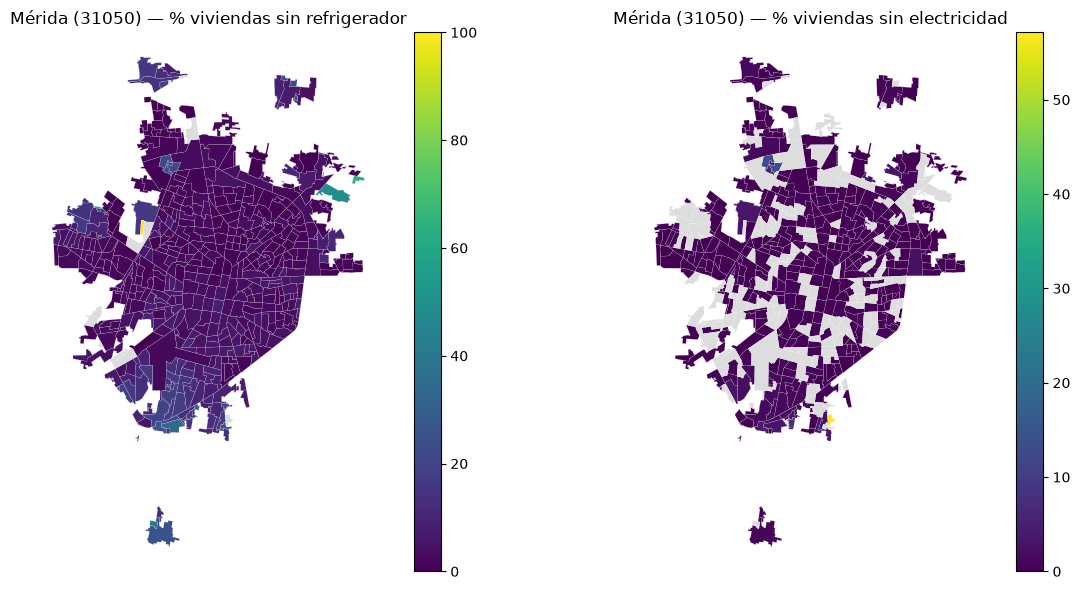

In [9]:
import matplotlib.pyplot as plt

ciudad = chk[chk["cve_ent"] + chk["cve_mun"] == "31050"]   # Mérida, Yuc.
fig, axs = plt.subplots(1, 2, figsize=(13, 6))
for ax, col, titulo in [(axs[0], "p_sin_refri", "% viviendas sin refrigerador"),
                        (axs[1], "p_sin_elec", "% viviendas sin electricidad")]:
    ciudad.plot(column=col, ax=ax, cmap="viridis", legend=True, edgecolor="white", linewidth=0.1,
                missing_kwds={"color": "#dddddd", "label": "censurado / sin viviendas"})
    ax.set_title(f"Mérida (31050) — {titulo}")
    ax.set_axis_off()
plt.tight_layout()